<a href="https://colab.research.google.com/github/Fatima-05/Task3-Heart-Disease-Prediction/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# problem statement and goal:

# build a machine learning model to predict whether a person is at risk of heart disease based on medical attributes.
# using the UCI Heart Disease dataset (Kaggle version).
# perform data cleaning and preprocessing.
# conduct exploratory data analysis (EDA) to understand trends and feature relationships.
# train classification models (Logistic Regression and Random Forest).
# evaluate the models using accuracy, confusion matrix, ROC curve, and AUC score.
# identify important features influencing heart disease prediction.

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# model and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# to ignore the warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# uploading the dataset after downloading from kaggle
from google.colab import files
uploaded = files.upload()

Saving HeartDiseaseTrain-Test.csv to HeartDiseaseTrain-Test.csv


In [3]:
# load the dataset

df = pd.read_csv("HeartDiseaseTrain-Test.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1025, 14)


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [21]:
# checking the structural info if the data set
df.info()
#the result shows that there are no missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 23 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   age                                       1025 non-null   int64  
 1   resting_blood_pressure                    1025 non-null   int64  
 2   cholestoral                               1025 non-null   int64  
 3   Max_heart_rate                            1025 non-null   int64  
 4   oldpeak                                   1025 non-null   float64
 5   target                                    1025 non-null   int64  
 6   sex_Male                                  1025 non-null   bool   
 7   chest_pain_type_Atypical angina           1025 non-null   bool   
 8   chest_pain_type_Non-anginal pain          1025 non-null   bool   
 9   chest_pain_type_Typical angina            1025 non-null   bool   
 10  fasting_blood_sugar_Lower than 120 m

In [5]:
# however still checking for and removing any missing value
print("\nMissing Values:\n")
print(df.isnull().sum())
df = df.dropna()

In [22]:
# converting the categorical data into numerical data so that it can be evaluated for predictions
df = pd.get_dummies(df, drop_first=True)

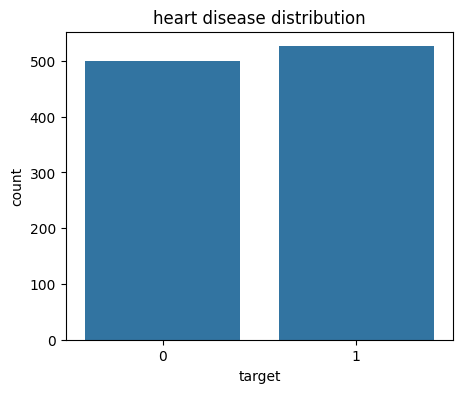

target
1    526
0    499
Name: count, dtype: int64


In [24]:
# EDA
# visualizing target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("heart disease distribution")
plt.show()
print(df['target'].value_counts())

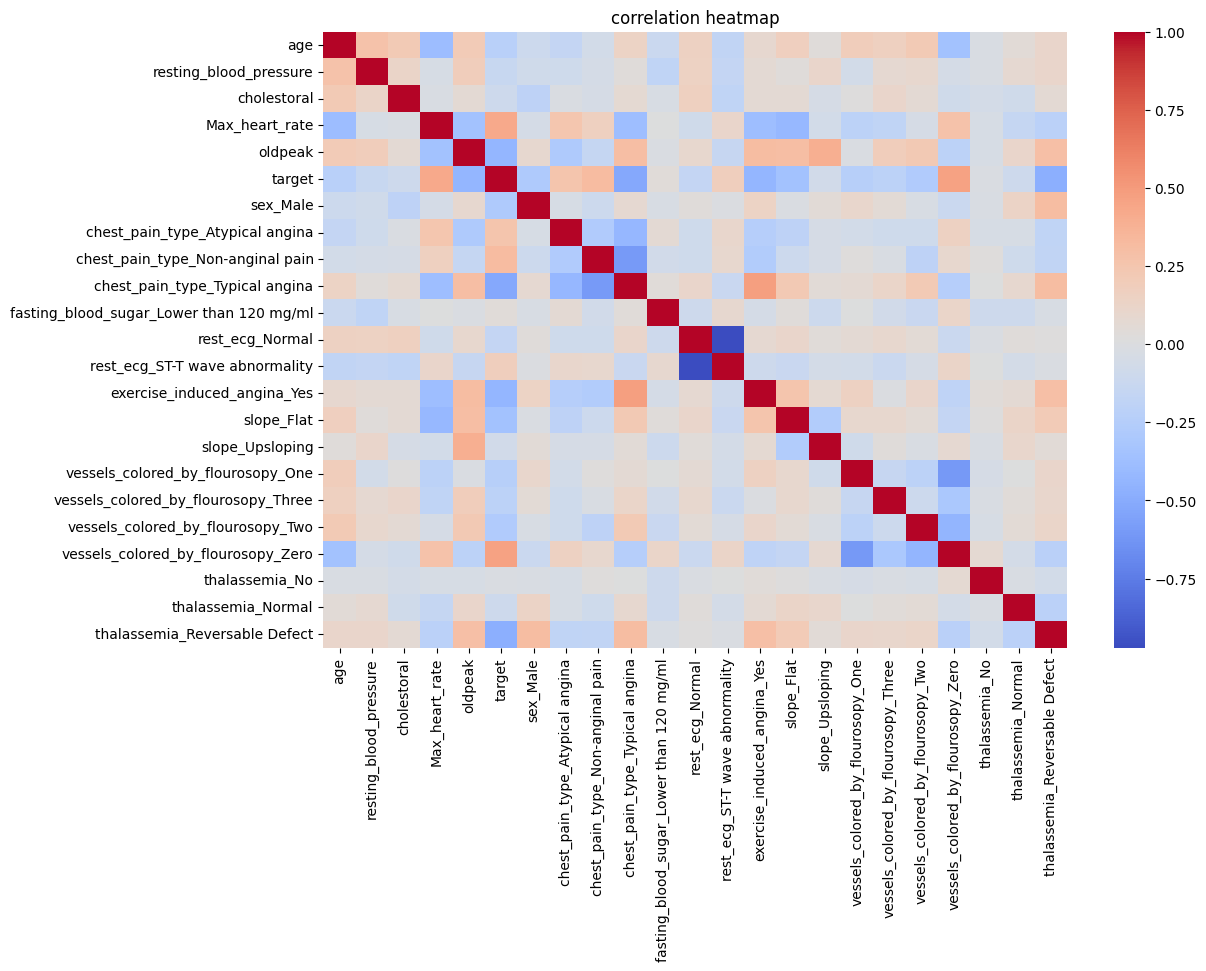

In [25]:
# using correaltion heatmap to understand the relation of each feature with all the other features
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("correlation heatmap")
plt.show()

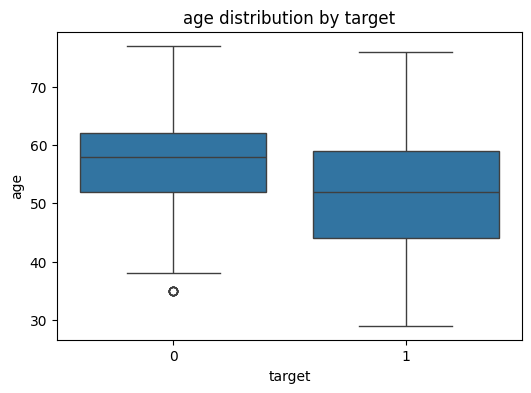

In [26]:
# boxplot to see the age distribution
plt.figure(figsize=(6,4))
sns.boxplot(x='target', y='age', data=df)
plt.title("age distribution by target")
plt.show()

In [27]:
# defining features and target

X = df.drop("target", axis=1)
y = df["target"]

# splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (820, 22)
Testing Shape: (205, 22)


In [13]:
# feature scaling as required by logistic regression model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# logistic regression model

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

# for predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

# for evaluation
log_accuracy = accuracy_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression Accuracy:", log_accuracy)
print("Logistic Regression AUC:", log_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8731707317073171
Logistic Regression AUC: 0.9454285714285715

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.84      0.87       100
           1       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



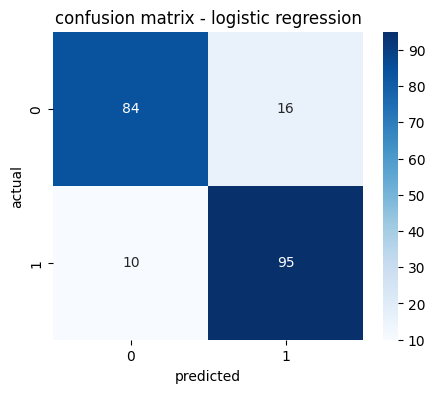

In [31]:
# cheching confusion matrix for logistic regression predictions
cm = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(5,4))
# plotting the confusion matrix as a heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("confusion matrix - logistic regression")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()

In [16]:
# random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# for predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# for evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest AUC:", rf_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 1.0
Random Forest AUC: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



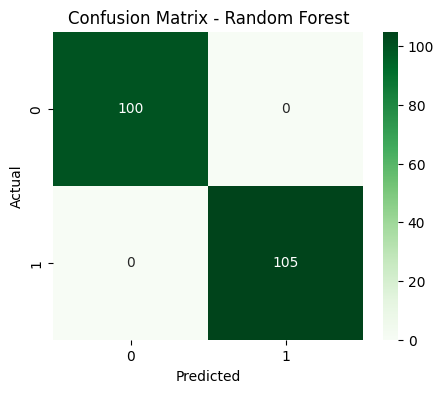

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


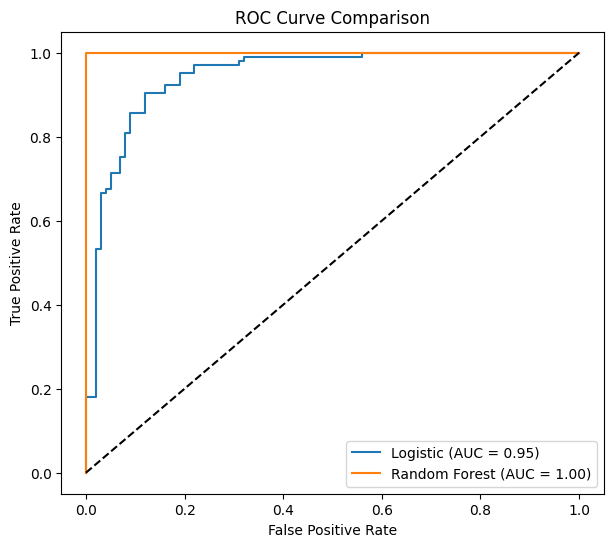

In [18]:
#ROC curve comparison
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {log_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


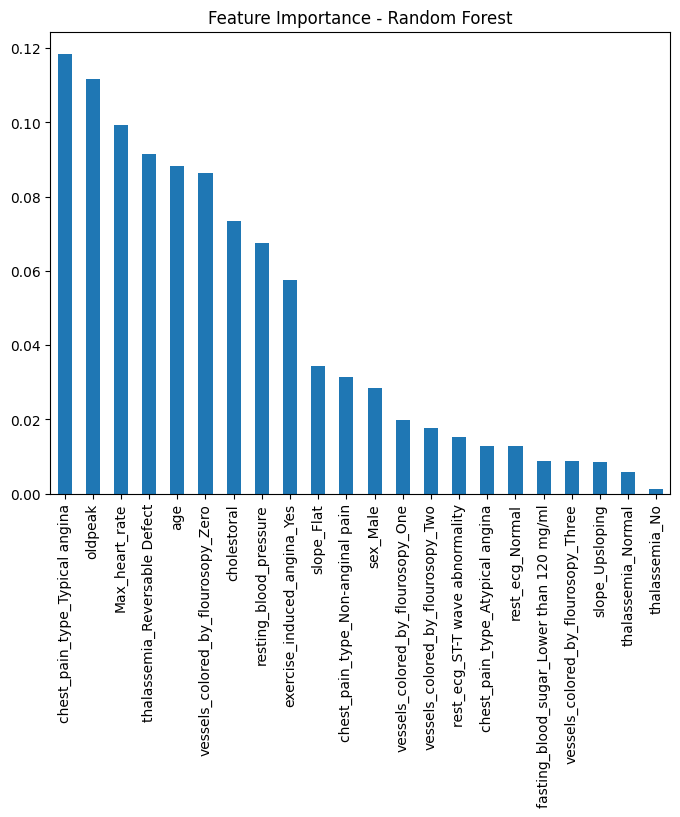

,0
chest_pain_type_Typical angina,0.118543
oldpeak,0.111637
Max_heart_rate,0.099309
thalassemia_Reversable Defect,0.091522
age,0.088272
vessels_colored_by_flourosopy_Zero,0.086315
cholestoral,0.073335
resting_blood_pressure,0.067453
exercise_induced_angina_Yes,0.057619
slope_Flat,0.034369


In [19]:
#featre importance analysis
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feature_importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.show()

feature_importance


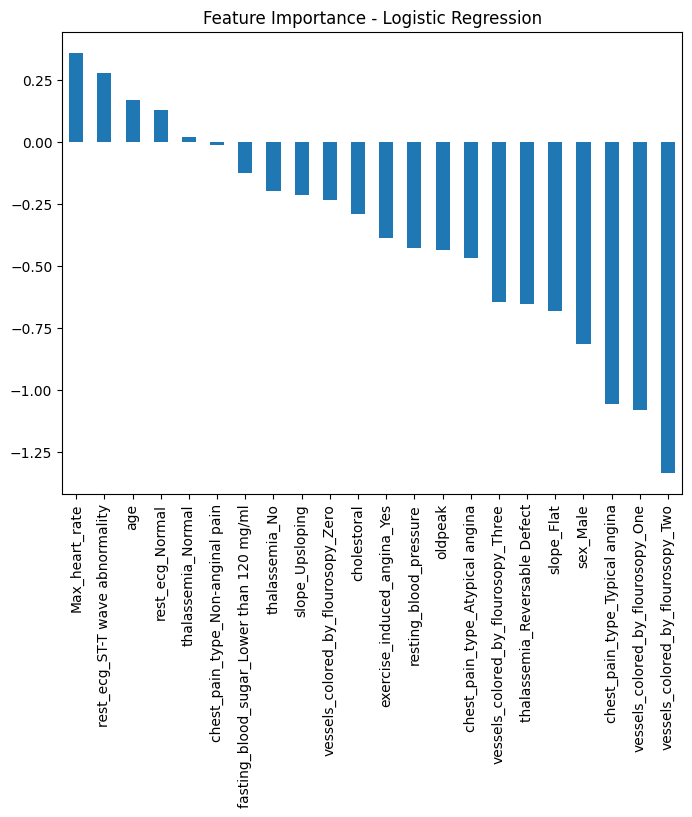

,0
Max_heart_rate,0.358937
rest_ecg_ST-T wave abnormality,0.275919
age,0.166759
rest_ecg_Normal,0.128043
thalassemia_Normal,0.019513
chest_pain_type_Non-anginal pain,-0.013059
fasting_blood_sugar_Lower than 120 mg/ml,-0.127475
thalassemia_No,-0.197157
slope_Upsloping,-0.213021
vessels_colored_by_flourosopy_Zero,-0.235535


In [20]:
# visualizing which feature affect heart disease predictions most
coefficients = pd.Series(
    log_model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
coefficients.plot(kind='bar')
plt.title("Feature Importance - Logistic Regression")
plt.show()

coefficients


In [ ]:
# results and final insights:

# random forest typically performs better than logistic regression.
# higher AUC score indicates better ability to distinguish between classes.
# important predictors often include chest pain type (cp), maximum heart rate (thalach),
# ST depression (oldpeak), number of major vessels (ca), and thalassemia (thal).
# patients with higher chest pain severity and abnormal ECG readings are more likely to have heart disease.
# random forest captured nonlinear relationships better than logistic regression.
# machine learning models can effectively predict heart disease risk using clinical features.
# random forest showed better performance and feature interpretability.